In [5]:
from qiskit import *
from qiskit.visualization import plot_histogram
%matplotlib inline

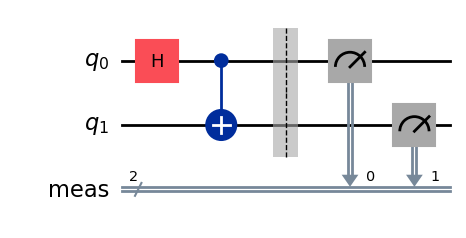

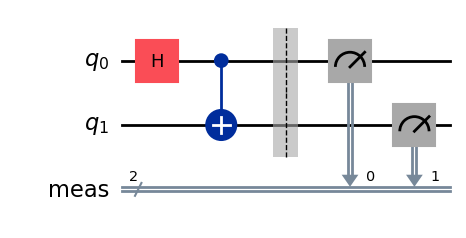

In [6]:
circuit = QuantumCircuit(2)
circuit.h(0)
circuit.cx(0, 1)
circuit.measure_all()
circuit.draw(output='mpl')

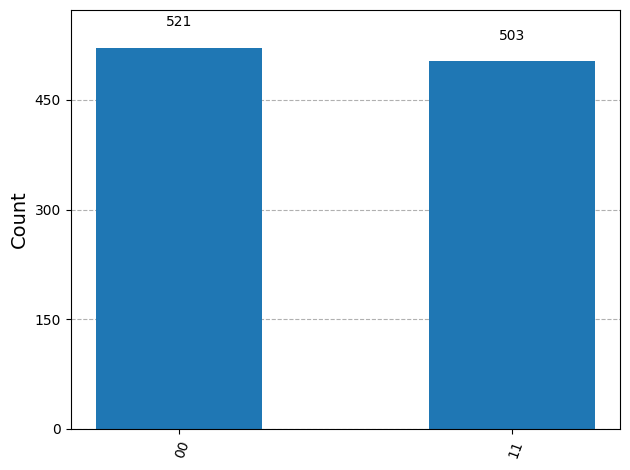

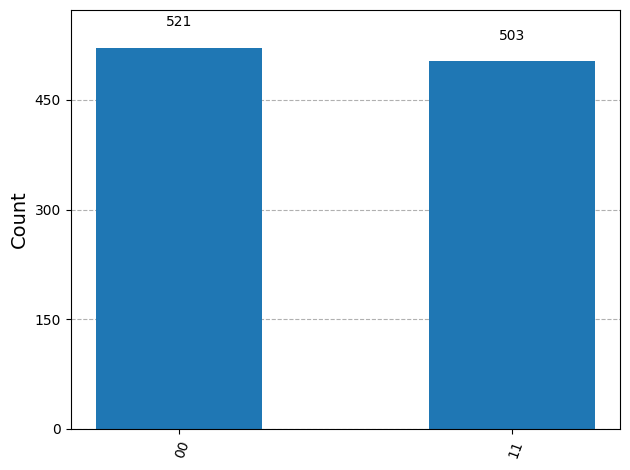

In [7]:
# UPDATE: Code updated after recording to resolve breaking changes from Qiskit 1.0
from qiskit.providers.basic_provider import BasicProvider
simulator = BasicProvider().get_backend('basic_simulator')
compiled_circuit = transpile(circuit, simulator)
result = simulator.run(compiled_circuit).result()
plot_histogram(result.get_counts())

In [8]:
#yea, ts not happenin'

from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2 as Sampler
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit.providers.basic_provider import BasicProvider
try:
  service = QiskitRuntimeService(channel='ibm_quantum_platform', token='1I4wWSiaZGqcPeONfFmdDIZ9YnXV538OTasiaDi44Gur', crn='crn:v1:bluemix:public:quantum-computing:us-east:a/727549f413624a06b034139b68c9ef14:a3a5c3d1-8577-450d-aa46-ab626150c165::')
  backend = service.least_busy(operational=True, simulator=False)
except Exception as e:
  print(f"Error connecting to IBM Quantum: {e}")
  print("Using local simulator instead")
  backend = BasicProvider().get_backend('basic_simulator')

try:
  service = QiskitRuntimeService(channel='ibm_quantum_platform', token='1I4wWSiaZGqcPeONfFmdDIZ9YnXV538OTasiaDi44Gur')
  backend = service.least_busy(operational=True, simulator=False)
except Exception as e:
  print(f"Error connecting to IBM Quantum: {e}")
  print("Using local simulator instead")
  backend = BasicProvider().get_backend('basic_simulator')

qcomp = backend

pm = generate_preset_pass_manager(backend=qcomp, optimization_level=1)
isa_circuit = pm.run(circuit)

sampler = Sampler(qcomp)
try:
  service = QiskitRuntimeService(channel='ibm_quantum_platform', token='1I4wWSiaZGqcPeONfFmdDIZ9YnXV538OTasiaDi44Gur')
  backend = service.least_busy(operational=True, simulator=False)
except Exception as e:
  print(f"Error connecting to IBM Quantum: {e}")
  print("Using local simulator instead")
  backend = BasicProvider().get_backend('basic_simulator')

qcomp = backend
pm = generate_preset_pass_manager(backend=qcomp, optimization_level=1)
isa_circuit = pm.run(circuit)

sampler = Sampler(qcomp)
job = sampler.run([isa_circuit], shots=1024)
result = job.result()
plot_histogram(result[0].data.meas.get_counts())

qiskit_runtime_service._discover_account:WARNING:2026-05-27 21:28:31,452: Loading account with the given token. A saved account will not be used.


Error connecting to IBM Quantum: QiskitRuntimeService.__init__() got an unexpected keyword argument 'crn'
Using local simulator instead


qiskit_runtime_service.__init__:WARNING:2026-05-27 21:28:34,460: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: Random Stuff. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.backends:WARNING:2026-05-27 21:28:35,547: Loading instance: Random Stuff, plan: open
qiskit_runtime_service.backends:WARNING:2026-05-27 21:28:37,863: Using instance: Random Stuff, plan: open
qiskit_runtime_service._discover_account:WARNING:2026-05-27 21:28:38,330: Loading account with the given token. A saved account will not be used.
qiskit_runtime_service.__init__:WARNING:2026-05-27 21:28:41,109: Instance was not set at service instantiation. Free and trial plan instances will be prioritized.

RuntimeInvalidStateError: 'Unable to retrieve result for job d8bm43b8ch0s738tpv6g. Job was cancelled.'

NameError: name 'service' is not defined